# Student Academic Outcome Prediction (Gupio AI/ML Assignment - Option 1)
Predict **Dropout / Enrolled / Graduate** using **enrollment-time information only**.

Workflow: load & inspect -> EDA -> leakage-safe split + preprocessing -> model comparison (CV on train) -> one-time test evaluation -> interpretation -> sample predictions.

All heavy lifting lives in `src/` so the notebook and `python -m src.train` give identical results. Run **Kernel > Restart & Run All** before submitting.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
warnings.filterwarnings('ignore')
import pandas as pd
from IPython.display import Image, display
from src.data_utils import *
from src.eda import run_eda
from src.train import run_training
from src.predict import demo_predictions
pd.set_option('display.width', 200, 'display.max_columns', 40)

## 1. Load & inspect
`data.csv` is semicolon-delimited; header whitespace is stripped, no data values are changed.

In [2]:
df = load_data(DATA_PATH)
print(run_eda(df))   # also writes outputs/data_overview.txt and EDA figures

Rows: 4424
Columns: 37 (36 inputs + Target expected)

Column dtypes:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tui

## 2. Exploratory data analysis (permitted enrollment-time features only)
The 12 `Curricular units ...` semester columns are **excluded** (they are not known at enrollment).

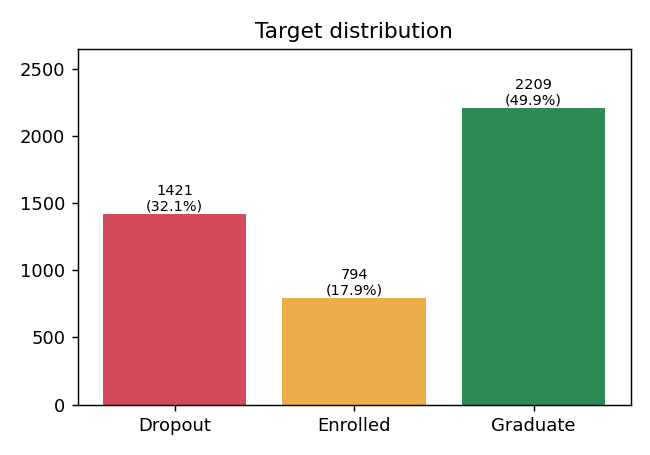

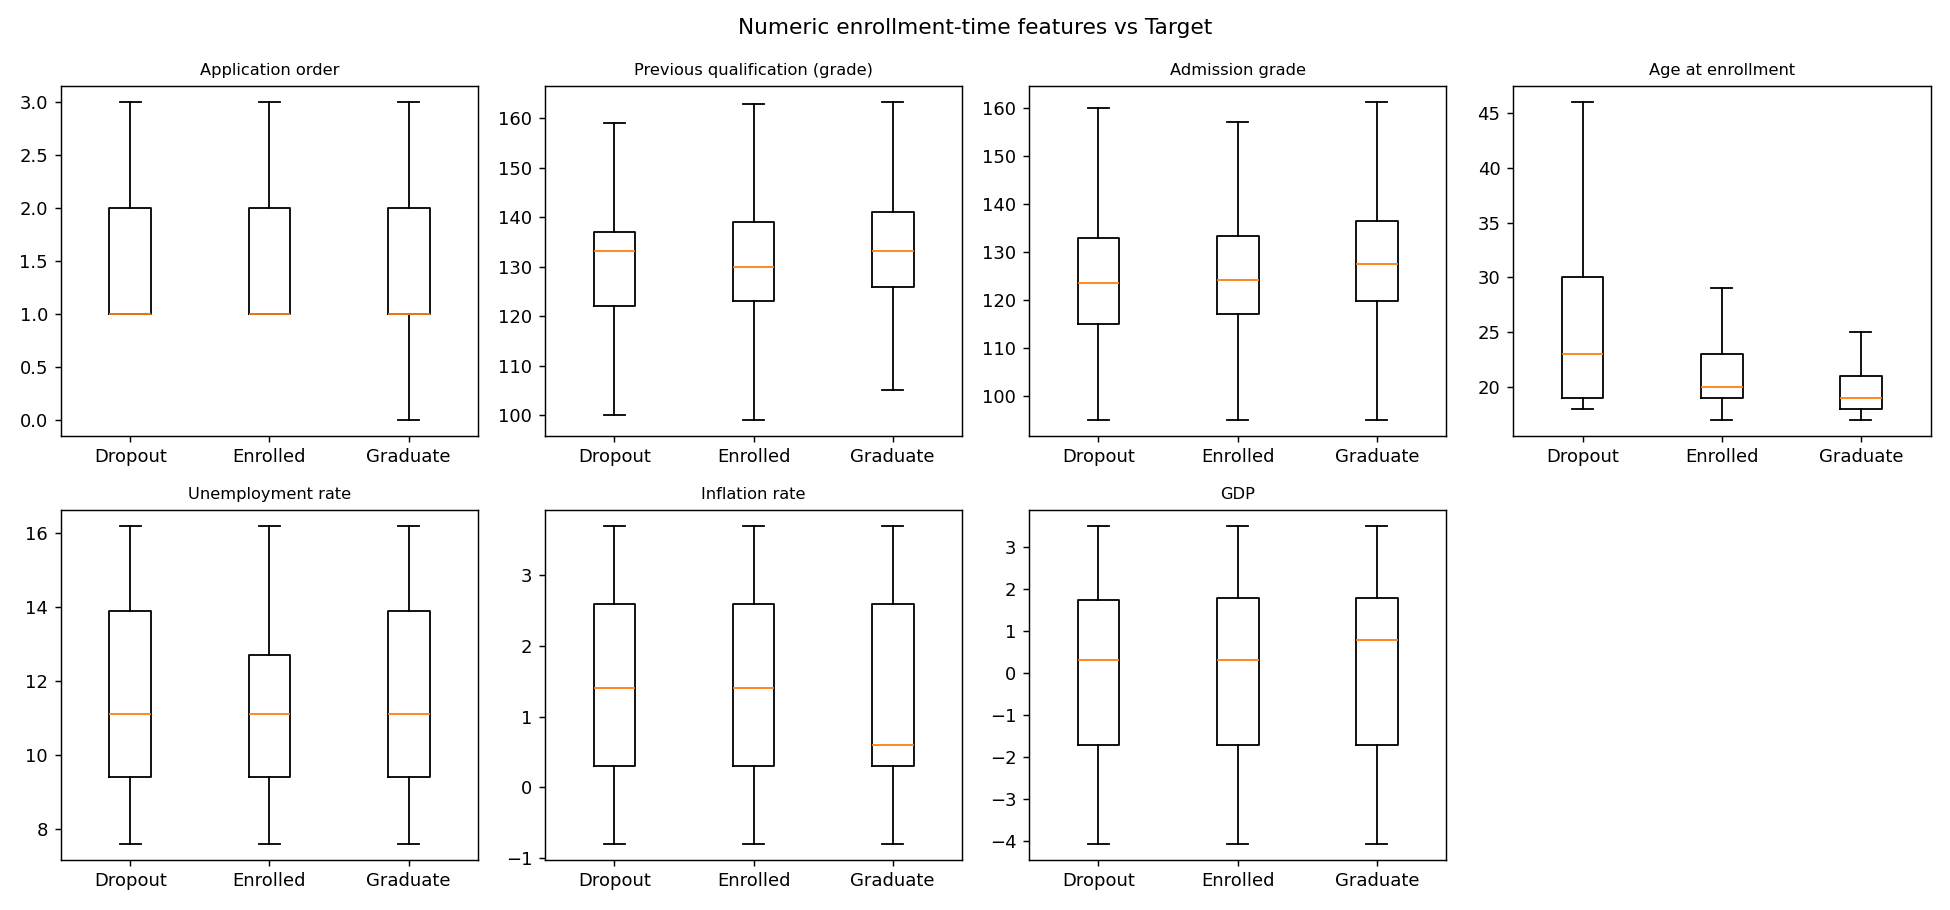

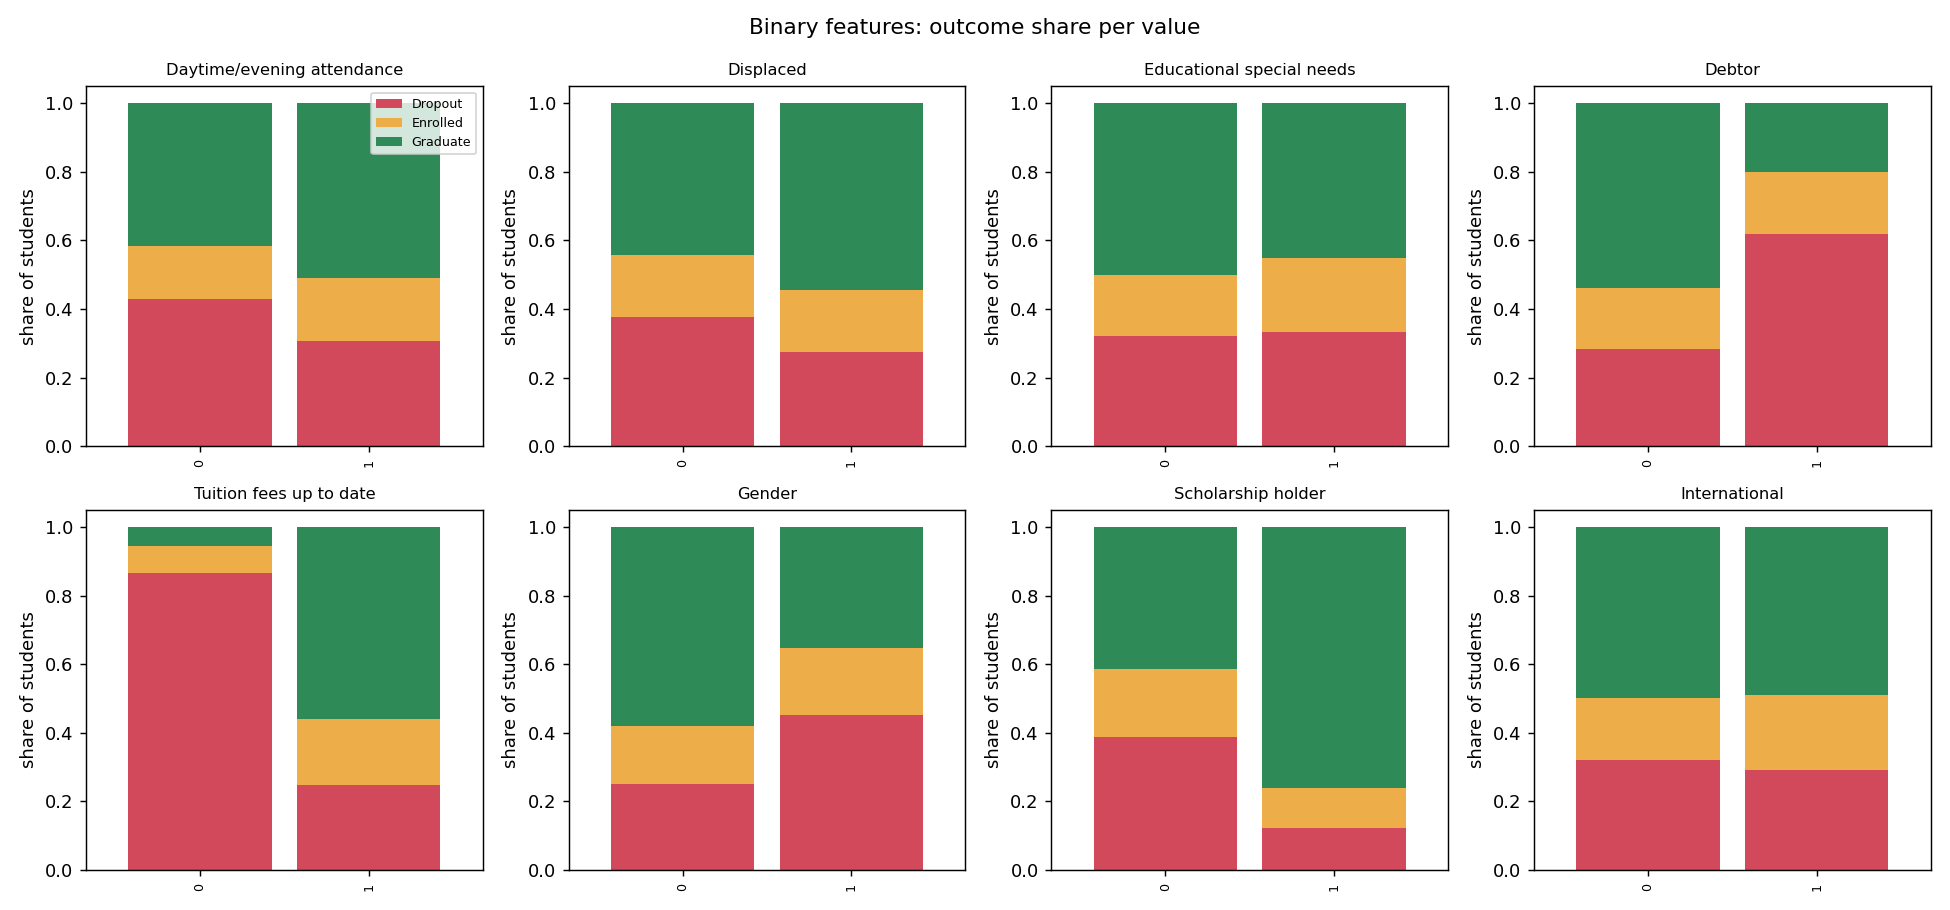

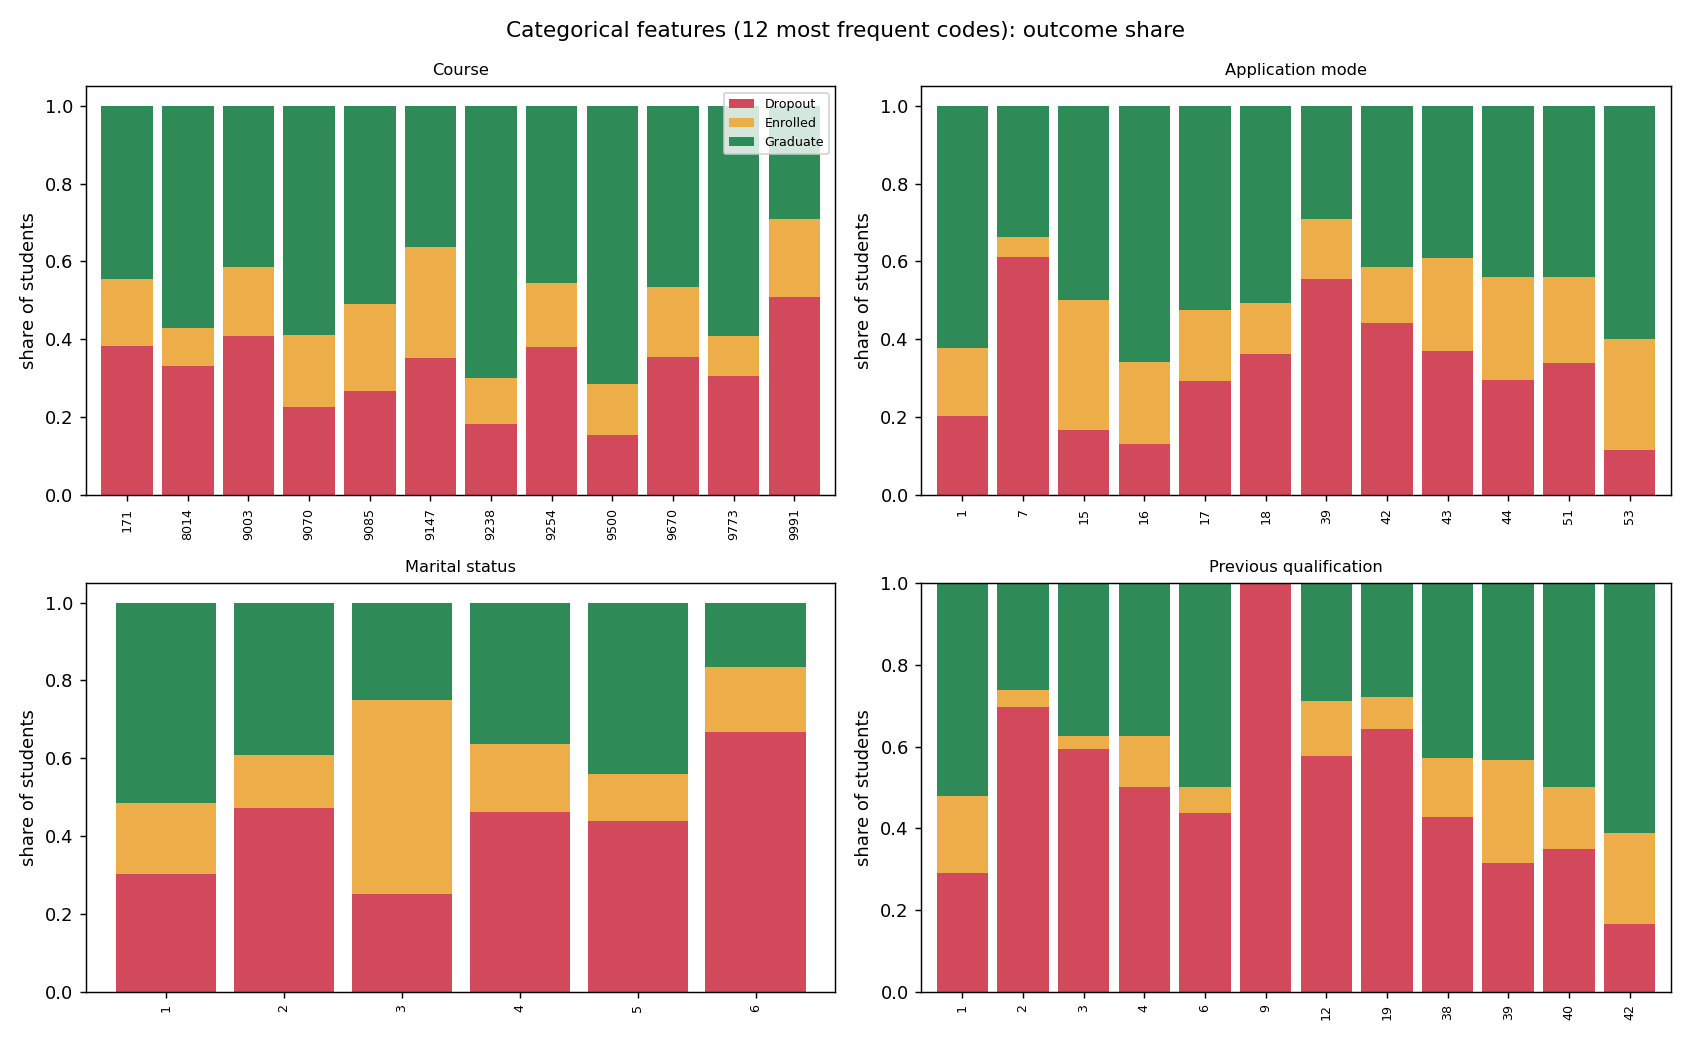

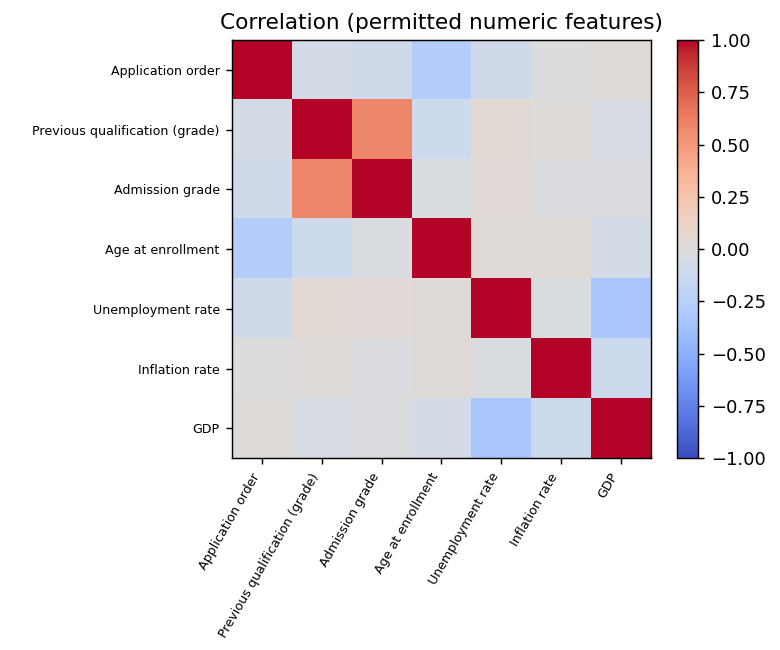

In [3]:
for f in ['eda_target_distribution','eda_numeric_vs_target','eda_binary_vs_target','eda_categorical_vs_target','eda_numeric_correlation']:
    display(Image(FIG_DIR / f'{f}.png'))

**EDA observations (write your own after viewing the plots above):**

- Class balance: ...
- Features that visibly separate the classes: ...
- Data-quality notes: ...

## 3. Split, preprocessing, model comparison, final test evaluation
- Stratified 80/20 split, `random_state=42`; the test set is only used after model selection.
- Imputation / scaling / one-hot encoding live **inside** the sklearn `Pipeline` -> fitted on training data only (also inside every CV fold).
- Models are selected by 5-fold CV macro-F1 on the training set; the test set is then scored once.

In [4]:
out = run_training(DATA_PATH, run_eda_step=False)
print('Selected:', out['best_name'])

Train: (3539, 24)  Test (held out): (885, 24)  Features used: 24


[CV] Dummy (most frequent)                macro-F1 = 0.2220  params = {}


[CV] Logistic Regression (unweighted)     macro-F1 = 0.5543  params = {'clf__C': 1.0}


[CV] Logistic Regression (balanced)       macro-F1 = 0.5743  params = {'clf__C': 0.1}


[CV] Random Forest (balanced)             macro-F1 = 0.5850  params = {'clf__max_depth': None, 'clf__min_samples_leaf': 5}

Selected final model (highest CV macro-F1 on training data): Random Forest (balanced)



                           model  selected  cv_macro_f1  test_accuracy  test_macro_precision  test_macro_recall  test_macro_f1  test_weighted_f1  Dropout_precision  Dropout_recall  Dropout_f1-score  Enrolled_precision  Enrolled_recall  Enrolled_f1-score  Graduate_precision  Graduate_recall  Graduate_f1-score
        Random Forest (balanced)      True       0.5850         0.5932                0.5397             0.5444         0.5414            0.5966             0.6013          0.6373            0.6188              0.3121           0.3396             0.3253              0.7056           0.6561             0.6800
  Logistic Regression (balanced)     False       0.5743         0.5831                0.5742             0.5738         0.5599            0.6002             0.6962          0.5810            0.6334              0.3082           0.5409             0.3927              0.7182           0.5995             0.6535
Logistic Regression (unweighted)     False       0.5543         0.6282

Selected: Random Forest (balanced)


In [5]:
cols = ['model','selected','cv_macro_f1','test_accuracy','test_macro_precision','test_macro_recall','test_macro_f1']
display(out['results'][cols].round(4))
per_class = [c for c in out['results'].columns if c.startswith(('Dropout_','Enrolled_','Graduate_'))]
display(out['results'][['model'] + per_class].round(3))

,model,selected,cv_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
3,Random Forest (balanced),True,0.5850,0.5932,0.5397,0.5444,0.5414
2,Logistic Regression (balanced),False,0.5743,0.5831,0.5742,0.5738,0.5599
1,Logistic Regression (unweighted),False,0.5543,0.6282,0.5441,0.5216,0.5195
0,Dummy (most frequent),False,0.2220,0.4994,0.1665,0.3333,0.2221


,model,Dropout_precision,Dropout_recall,Dropout_f1-score,Enrolled_precision,Enrolled_recall,Enrolled_f1-score,Graduate_precision,Graduate_recall,Graduate_f1-score
3,Random Forest (balanced),0.601,0.637,0.619,0.312,0.340,0.325,0.706,0.656,0.680
2,Logistic Regression (balanced),0.696,0.581,0.633,0.308,0.541,0.393,0.718,0.600,0.654
1,Logistic Regression (unweighted),0.665,0.588,0.624,0.312,0.151,0.203,0.655,0.826,0.731
0,Dummy (most frequent),0.000,0.000,0.000,0.000,0.000,0.000,0.499,1.000,0.666


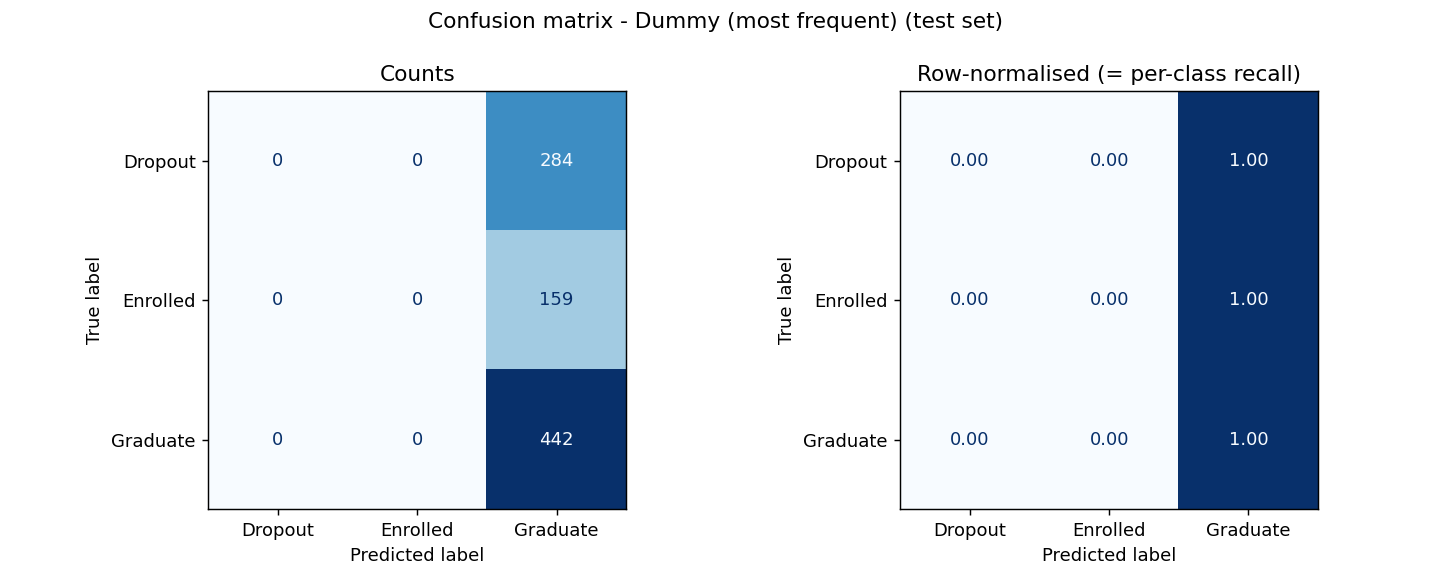

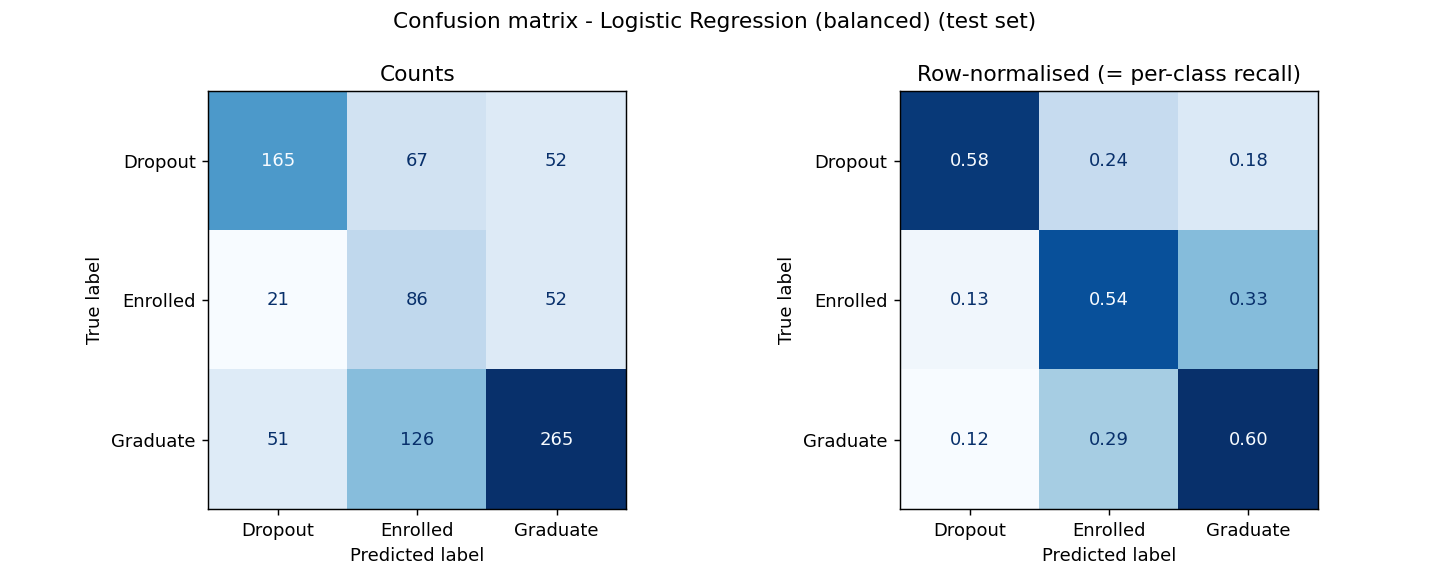

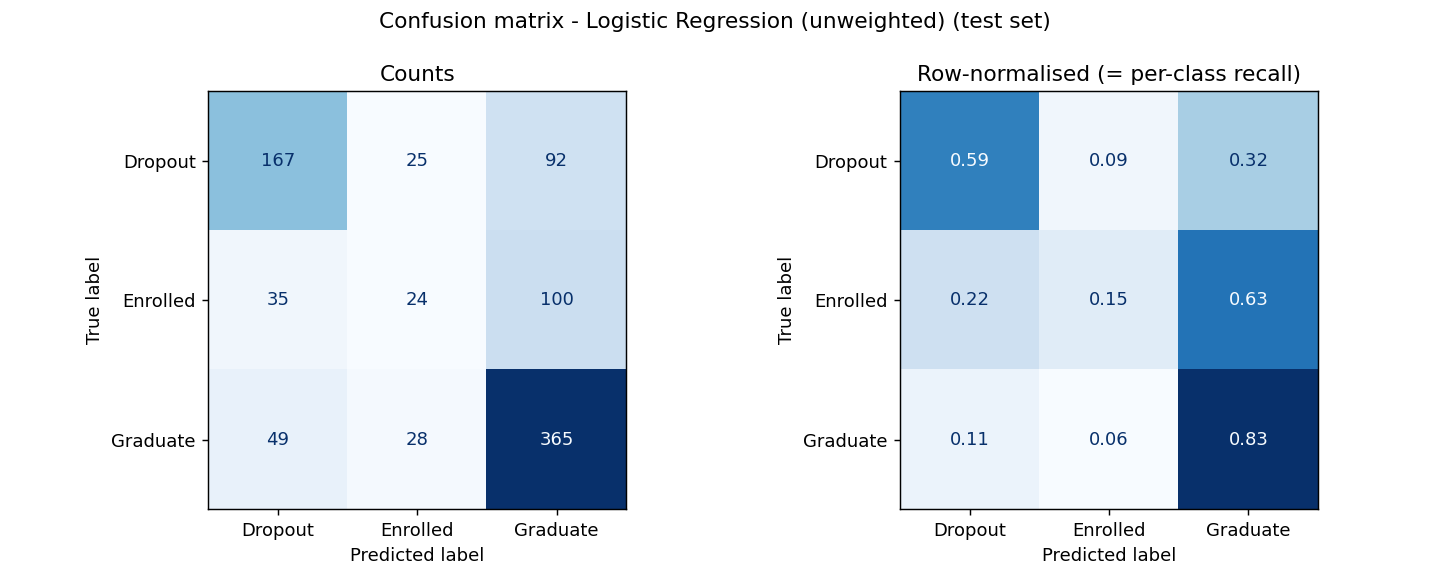

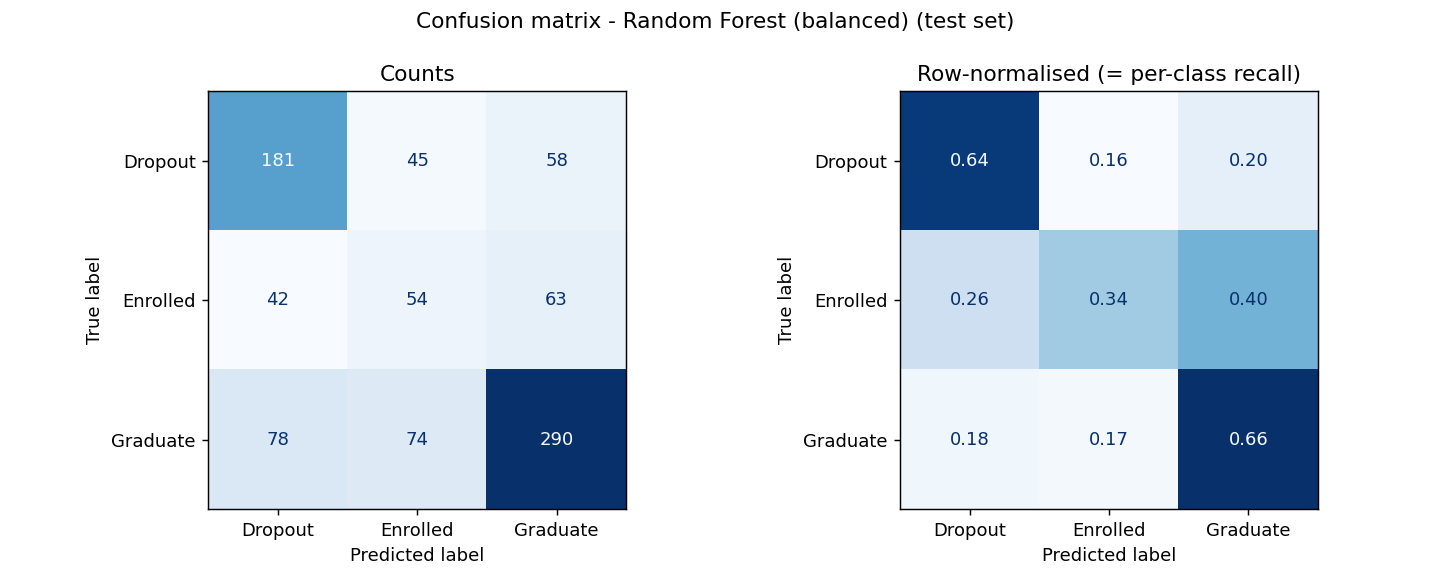

In [6]:
import glob
for p in sorted(glob.glob(str(FIG_DIR / 'cm_*.png'))):
    display(Image(p))

In [7]:
print(open(OUTPUT_DIR / ('classification_report_' + __import__('src.train', fromlist=['_safe'])._safe(out['best_name']) + '.txt')).read())

Random Forest (balanced)
best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 5}

              precision    recall  f1-score   support

     Dropout      0.601     0.637     0.619       284
    Enrolled      0.312     0.340     0.325       159
    Graduate      0.706     0.656     0.680       442

    accuracy                          0.593       885
   macro avg      0.540     0.544     0.541       885
weighted avg      0.601     0.593     0.597       885



**Discussion (write your own after viewing the results):**

- Class imbalance effect and which class is handled well / poorly: ...
- Why the final model was chosen (macro-F1 / per-class recall, not accuracy alone): ...

## 4. Interpretation of important features
Permutation importance on the held-out test set - shows **association/predictive usefulness, not causation**.

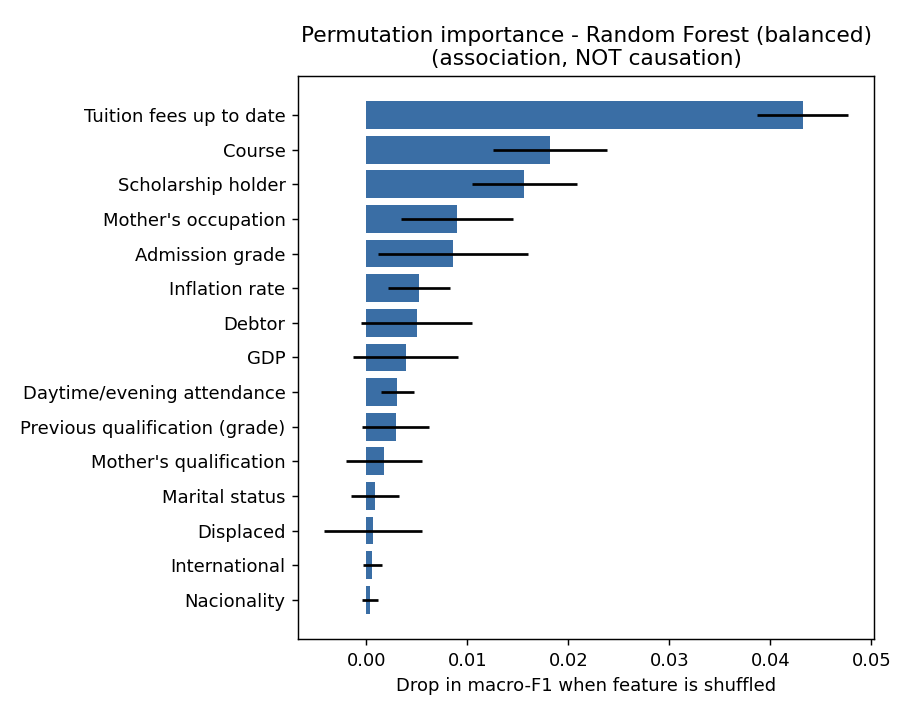

,feature,importance_mean,importance_std
11,Tuition fees up to date,0.0432,0.0045
17,Course,0.0182,0.0057
13,Scholarship holder,0.0156,0.0052
22,Mother's occupation,0.0090,0.0056
2,Admission grade,0.0086,0.0075
5,Inflation rate,0.0052,0.0031
10,Debtor,0.0050,0.0055
6,GDP,0.0039,0.0052
7,Daytime/evening attendance,0.0031,0.0017
1,Previous qualification (grade),0.0029,0.0033


In [8]:
display(Image(FIG_DIR / 'permutation_importance.png'))
display(out['importance'].head(10).round(4))

## 5. Sample predictions (same saved pipeline = same preprocessing as training)

In [9]:
demo = demo_predictions(n_per_class=2)
demo.to_csv(OUTPUT_DIR / 'sample_predictions.csv')
demo

,Course,Age at enrollment,Admission grade,Gender,Scholarship holder,Debtor,actual,predicted,P(Dropout),P(Enrolled),P(Graduate),correct
4055,9085,28,110.0,0,0,0,Dropout,Dropout,0.559,0.261,0.180,True
3003,9556,19,119.0,0,1,0,Dropout,Graduate,0.156,0.193,0.651,False
3653,9085,20,140.0,0,0,0,Enrolled,Enrolled,0.171,0.538,0.291,True
186,9238,21,126.6,0,0,1,Enrolled,Dropout,0.657,0.180,0.164,False
2271,9070,23,178.0,1,1,0,Graduate,Graduate,0.219,0.311,0.470,True
168,9500,29,130.0,0,0,0,Graduate,Dropout,0.494,0.240,0.266,False


## 6. Limitations
See README.md (prediction vs causation, single institution, enrollment-time features only, small 'Enrolled' class, etc.).